In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
print("\n1. PRIMERAS FILAS DEL DATASET:")
print(df.head(10))


1. PRIMERAS FILAS DEL DATASET:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   
5          6    15574012       Chu          645     Spain    Male   44   
6          7    15592531  Bartlett          822    France    Male   50   
7          8    15656148    Obinna          376   Germany  Female   29   
8          9    15792365        He          501    France    Male   44   
9         10    15592389        H?          684    France    Male   27   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86 

In [4]:
print("\n2. INFORMACIÓN GENERAL DEL DATASET:")
print(df.info())


2. INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [5]:
print("\n3. DIMENSIONES DEL DATASET:")
print(f"Número de registros: {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")


3. DIMENSIONES DEL DATASET:
Número de registros: 10,000
Número de variables: 14


In [6]:
print("\n4. RESUMEN ESTADÍSTICO:")
print(df.describe())


4. RESUMEN ESTADÍSTICO:


         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

In [7]:
print("\n5. VALORES FALTANTES:")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")


5. VALORES FALTANTES:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total de valores faltantes: 0


In [8]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print("\nDistribución de Churn:")
print(f"Clientes Activos (0): {churn_counts[0]:,} ({churn_pct[0]:.2f}%)")
print(f"Clientes que Abandonaron (1): {churn_counts[1]:,} ({churn_pct[1]:.2f}%)")
print(f"\nTasa de Churn: {churn_pct[1]:.2f}%")


Distribución de Churn:
Clientes Activos (0): 7,963 (79.63%)
Clientes que Abandonaron (1): 2,037 (20.37%)

Tasa de Churn: 20.37%


C:\Users\alex_\AppData\Local\Temp\ipykernel_21540\175911719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', ax=axes[0], palette=['#EDF268', '#F26D68'])


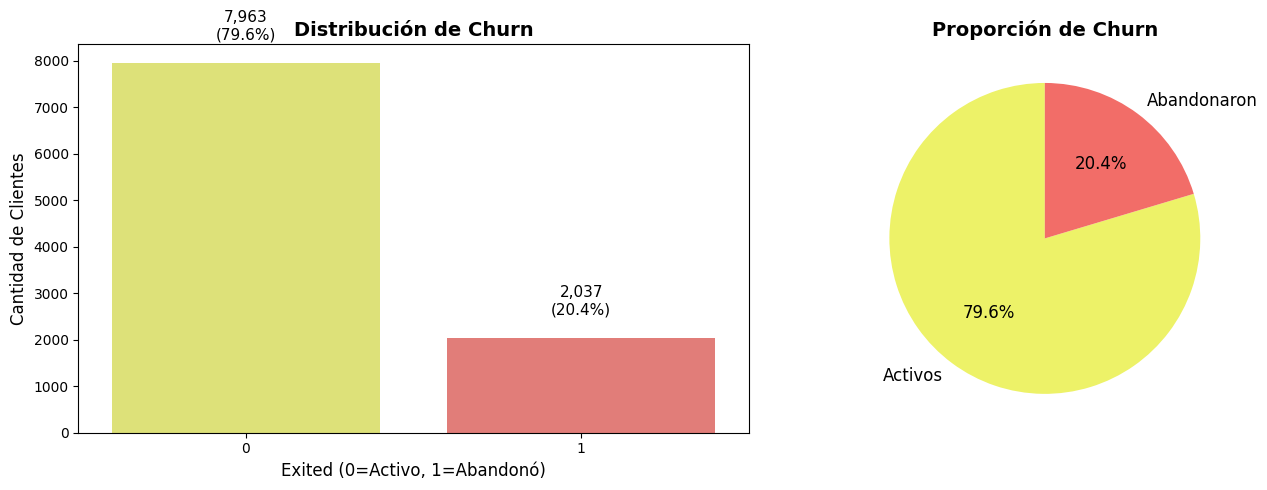

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Exited', ax=axes[0], palette=['#EDF268', '#F26D68'])
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Exited (0=Activo, 1=Abandonó)', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 500, f'{v:,}\n({churn_pct[i]:.1f}%)', ha='center', fontsize=11)

colors = ['#EDF268', '#F26D68']
axes[1].pie(churn_counts, labels=['Activos', 'Abandonaron'], autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
print("\n--- EDAD ---")
print(df['Age'].describe())
print(f"Edad promedio de clientes que abandonaron: {df[df['Exited']==1]['Age'].mean():.2f}")
print(f"Edad promedio de clientes activos: {df[df['Exited']==0]['Age'].mean():.2f}")


--- EDAD ---
count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64
Edad promedio de clientes que abandonaron: 44.84
Edad promedio de clientes activos: 37.41


In [11]:
print("\n--- GÉNERO ---")
print(df['Gender'].value_counts())
print("\nTasa de churn por género:")
print(df.groupby('Gender')['Exited'].mean().sort_values(ascending=False))


--- GÉNERO ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Tasa de churn por género:
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


In [12]:
print("\n--- GEOGRAFÍA ---")
print(df['Geography'].value_counts())
print("\nTasa de churn por país:")
print(df.groupby('Geography')['Exited'].mean().sort_values(ascending=False))


--- GEOGRAFÍA ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Tasa de churn por país:
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64


C:\Users\alex_\AppData\Local\Temp\ipykernel_21540\4269806811.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Age', ax=axes[0,1], palette=['#EDF268', '#F26D68'])
C:\Users\alex_\AppData\Local\Temp\ipykernel_21540\4269806811.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Activo', 'Abandonó'])


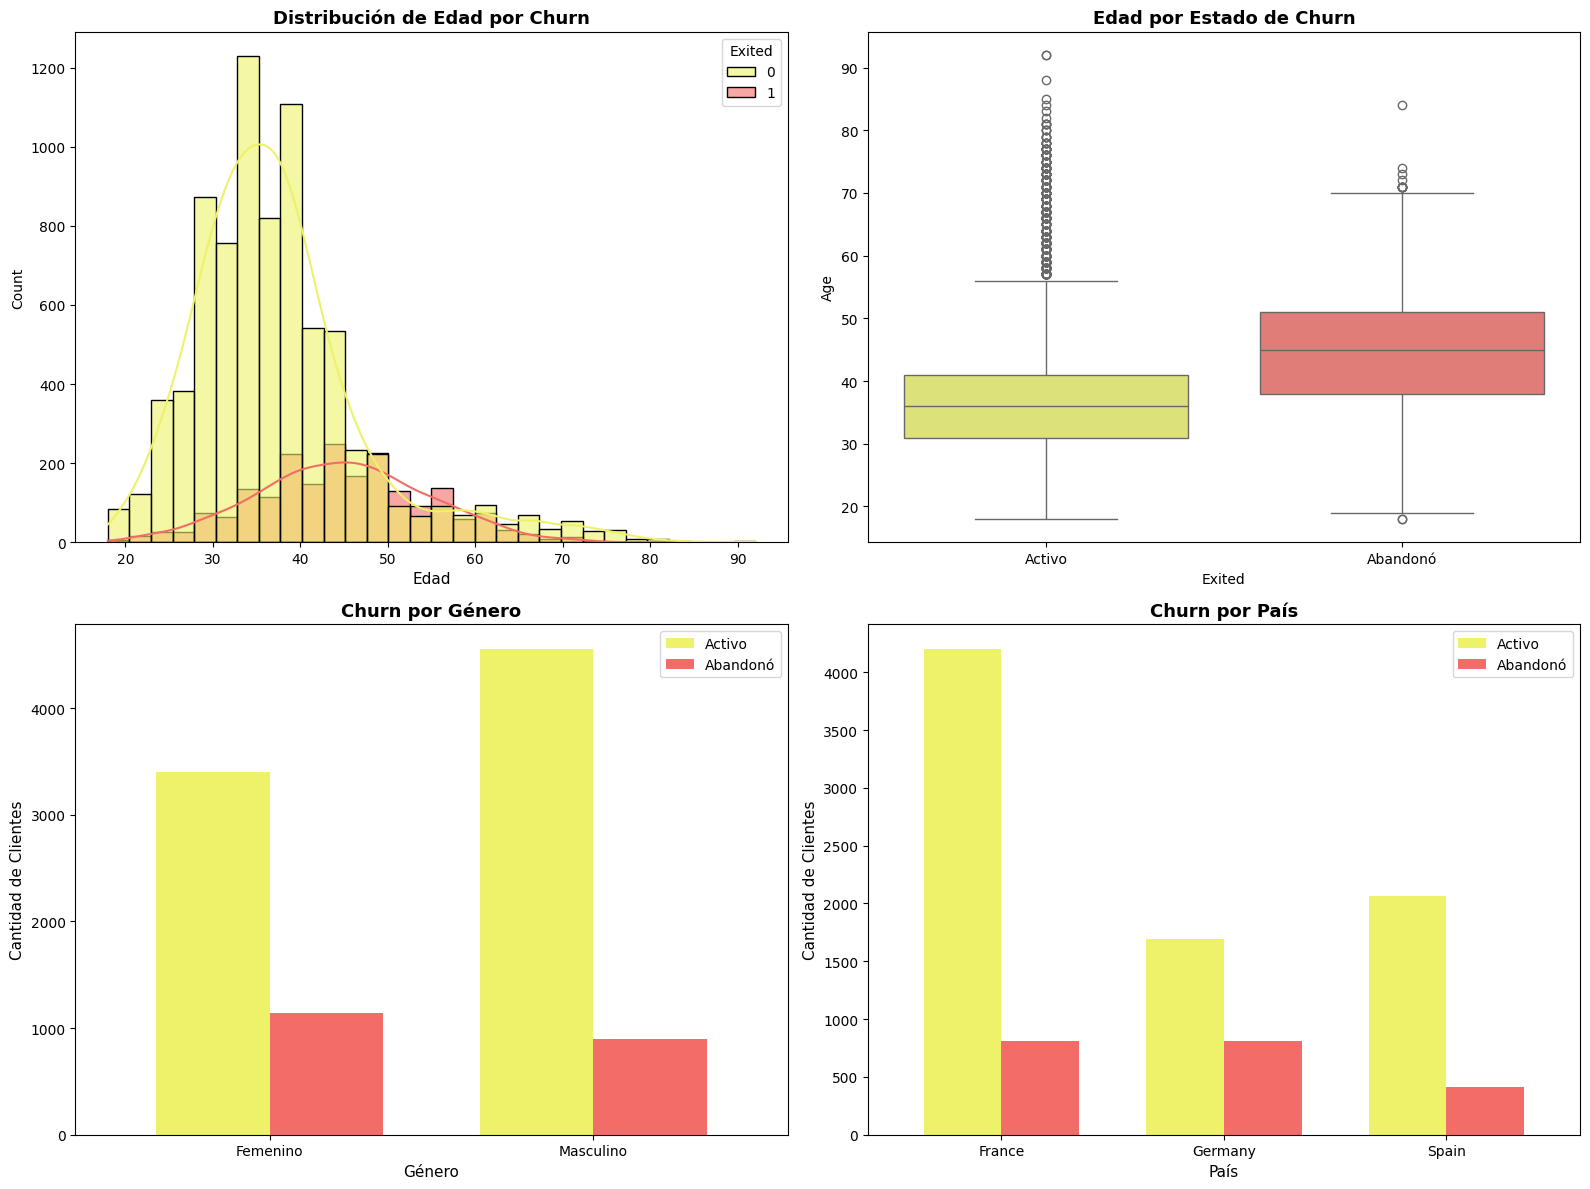

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(data=df, x='Age', hue='Exited', bins=30, ax=axes[0,0], 
             palette=['#EDF268', '#F26D68'], alpha=0.6, kde=True)
axes[0,0].set_title('Distribución de Edad por Churn', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Edad', fontsize=11)

sns.boxplot(data=df, x='Exited', y='Age', ax=axes[0,1], palette=['#EDF268', '#F26D68'])
axes[0,1].set_title('Edad por Estado de Churn', fontsize=13, fontweight='bold')
axes[0,1].set_xticklabels(['Activo', 'Abandonó'])

gender_churn = df.groupby(['Gender', 'Exited']).size().unstack()
gender_churn.plot(kind='bar', ax=axes[1,0], color=['#EDF268', '#F26D68'], width=0.7)
axes[1,0].set_title('Churn por Género', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Género', fontsize=11)
axes[1,0].set_ylabel('Cantidad de Clientes', fontsize=11)
axes[1,0].legend(['Activo', 'Abandonó'])
axes[1,0].set_xticklabels(['Femenino', 'Masculino'], rotation=0)

geo_churn = df.groupby(['Geography', 'Exited']).size().unstack()
geo_churn.plot(kind='bar', ax=axes[1,1], color=['#EDF268', '#F26D68'], width=0.7)
axes[1,1].set_title('Churn por País', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('País', fontsize=11)
axes[1,1].set_ylabel('Cantidad de Clientes', fontsize=11)
axes[1,1].legend(['Activo', 'Abandonó'])
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [14]:
financial_vars = ['CreditScore', 'Balance', 'EstimatedSalary', 'NumOfProducts', 'Tenure']

for var in financial_vars:
    print(f"\n--- {var.upper()} ---")
    print(df[var].describe())
    print(f"Promedio para clientes que abandonaron: {df[df['Exited']==1][var].mean():.2f}")
    print(f"Promedio para clientes activos: {df[df['Exited']==0][var].mean():.2f}")


--- CREDITSCORE ---
count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64
Promedio para clientes que abandonaron: 645.35
Promedio para clientes activos: 651.85

--- BALANCE ---
count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64
Promedio para clientes que abandonaron: 91108.54
Promedio para clientes activos: 72745.30

--- ESTIMATEDSALARY ---
count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64
Promedio para clientes que abandonaron: 101465.68
Promedio para clientes activos: 99738.39

--- NUMOFPRODUCTS ---
c

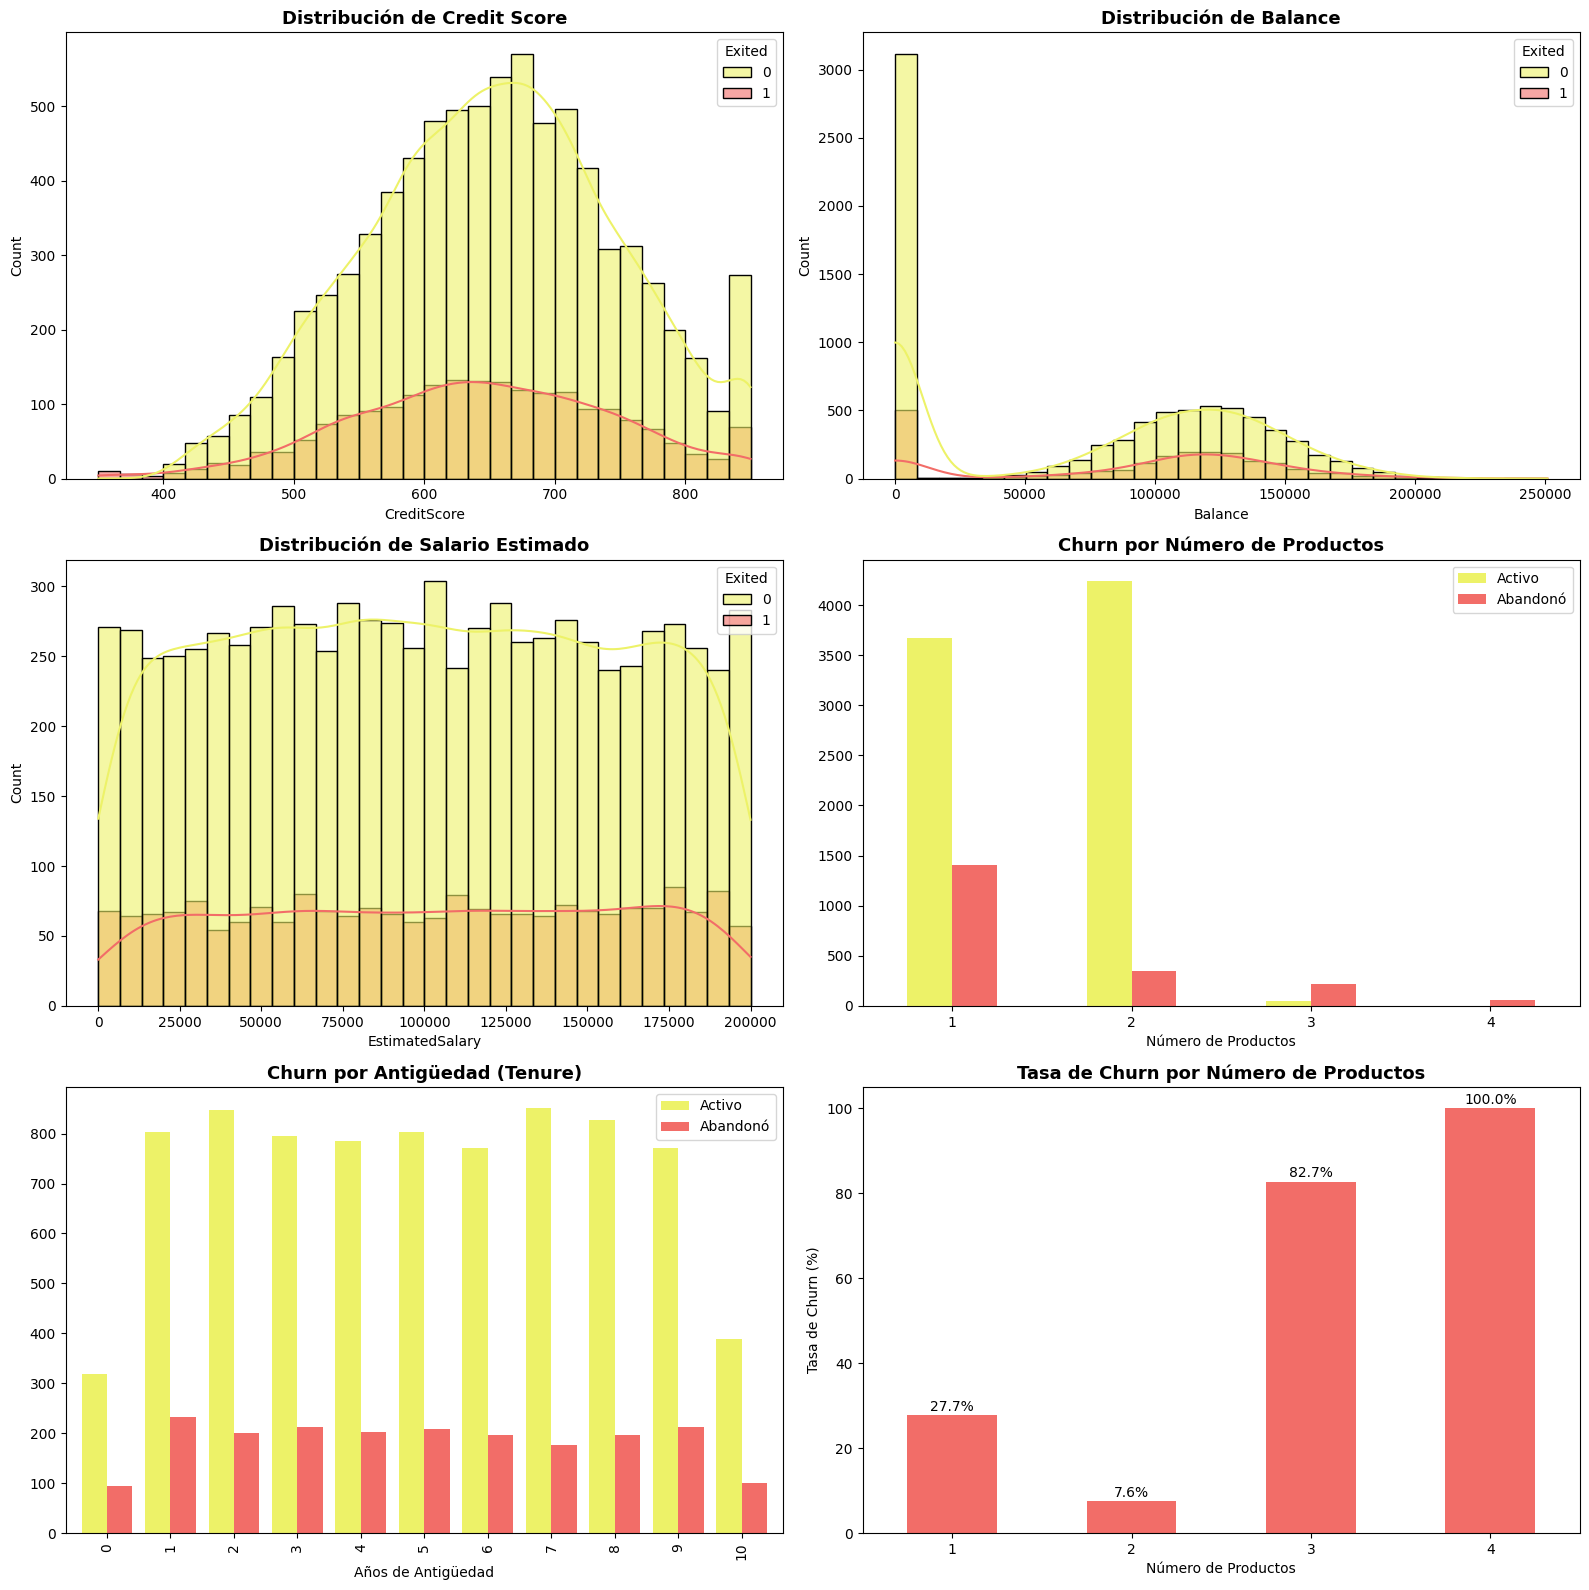

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

sns.histplot(data=df, x='CreditScore', hue='Exited', bins=30, ax=axes[0,0],
             palette=['#EDF268', '#F26D68'], alpha=0.6, kde=True)
axes[0,0].set_title('Distribución de Credit Score', fontsize=13, fontweight='bold')

sns.histplot(data=df, x='Balance', hue='Exited', bins=30, ax=axes[0,1],
             palette=['#EDF268', '#F26D68'], alpha=0.6, kde=True)
axes[0,1].set_title('Distribución de Balance', fontsize=13, fontweight='bold')

sns.histplot(data=df, x='EstimatedSalary', hue='Exited', bins=30, ax=axes[1,0],
             palette=['#EDF268', '#F26D68'], alpha=0.6, kde=True)
axes[1,0].set_title('Distribución de Salario Estimado', fontsize=13, fontweight='bold')

products_churn = df.groupby(['NumOfProducts', 'Exited']).size().unstack(fill_value=0)
products_churn.plot(kind='bar', ax=axes[1,1], color=['#EDF268', '#F26D68'])
axes[1,1].set_title('Churn por Número de Productos', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Número de Productos')
axes[1,1].legend(['Activo', 'Abandonó'])
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

tenure_churn = df.groupby(['Tenure', 'Exited']).size().unstack(fill_value=0)
tenure_churn.plot(kind='bar', ax=axes[2,0], color=['#EDF268', '#F26D68'], width=0.8)
axes[2,0].set_title('Churn por Antigüedad (Tenure)', fontsize=13, fontweight='bold')
axes[2,0].set_xlabel('Años de Antigüedad')
axes[2,0].legend(['Activo', 'Abandonó'])

churn_by_products = df.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', ax=axes[2,1], color='#F26D68')
axes[2,1].set_title('Tasa de Churn por Número de Productos', fontsize=13, fontweight='bold')
axes[2,1].set_ylabel('Tasa de Churn (%)')
axes[2,1].set_xlabel('Número de Productos')
axes[2,1].set_xticklabels(axes[2,1].get_xticklabels(), rotation=0)
for i, v in enumerate(churn_by_products):
    axes[2,1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()


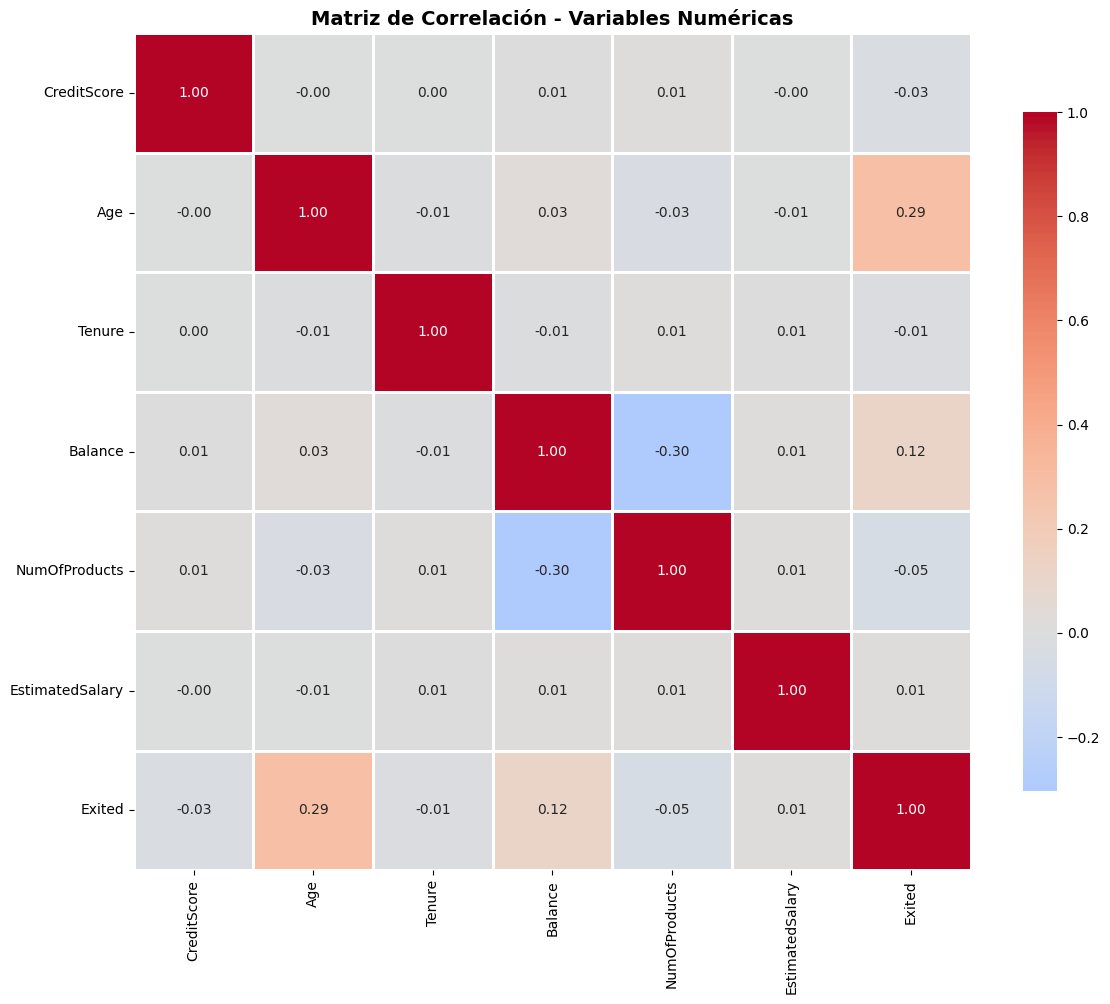


Correlación con la variable objetivo (Exited):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Name: Exited, dtype: float64


In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['RowNumber','CustomerId','IsActiveMember','HasCrCard']).tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelación con la variable objetivo (Exited):")
print(correlation_matrix['Exited'].sort_values(ascending=False))

In [31]:
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

cat_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

print(f"\nVariables categóricas: {cat_features}")
print(f"Variables numéricas: {num_features}")

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = X[num_features]
vif_data = pd.DataFrame()
vif_data["Variable"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(len(X_numeric.columns))]

print("\nANÁLISIS DE MULTICOLINEALIDAD")
print("VIF < 5: No hay multicolinealidad significativa")
print("VIF 5-10: Multicolinealidad moderada")
print("VIF > 10: Multicolinealidad alta")

print("\n", vif_data.sort_values('VIF', ascending=False))


Variables categóricas: ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
Variables numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

ANÁLISIS DE MULTICOLINEALIDAD
VIF < 5: No hay multicolinealidad significativa
VIF 5-10: Multicolinealidad moderada
VIF > 10: Multicolinealidad alta

           Variable        VIF
0      CreditScore  19.442916
1              Age  12.020539
4    NumOfProducts   7.658841
5  EstimatedSalary   3.882556
2           Tenure   3.850015
3          Balance   2.622428


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTamaño del conjunto entrenamiento: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto prueba: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nDistribución de churn en train:")
print(y_train.value_counts(normalize=True))
print("\nDistribución de churn en test:")
print(y_test.value_counts(normalize=True))

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_features),('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(max_iter=1000, random_state=42))])


pipeline.fit(X_train, y_train)


Tamaño del conjunto entrenamiento: 8,000 (80.0%)
Tamaño del conjunto prueba: 2,000 (20.0%)

Distribución de churn en train:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Distribución de churn en test:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


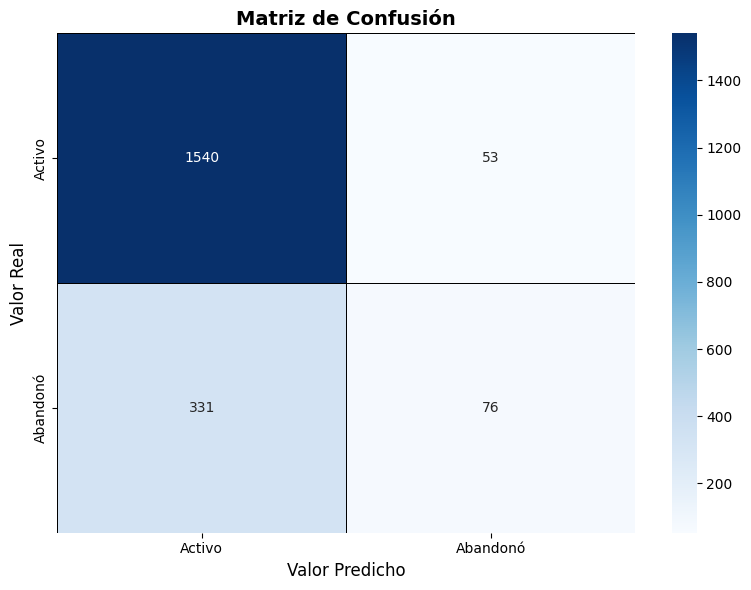

In [19]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linecolor='black', linewidths=0.5, xticklabels=['Activo', 'Abandonó'], yticklabels=['Activo', 'Abandonó'])
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Predicho', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, accuracy_score
print("\n REPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred, target_names=['Activo', 'Abandonó']))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


 REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

      Activo       0.82      0.97      0.89      1593
    Abandonó       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Accuracy: 0.8080


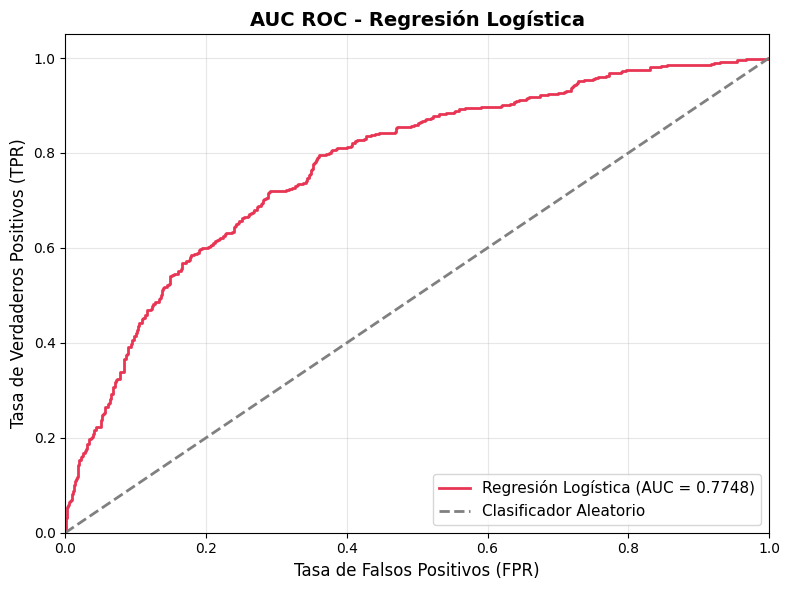

AUC-ROC Score: 0.7748


In [32]:
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#E83554', lw=2, label=f'Regresión Logística (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('AUC ROC - Regresión Logística', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC Score: {roc_auc:.4f}")

In [36]:
log_model = pipeline.named_steps['classifier']
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_model.coef_[0]
})
coefs = coefs.sort_values('Coefficient', ascending=False)

print("\nCOEFICIENTES (LOG-ODDS)")
print(coefs)


COEFICIENTES (LOG-ODDS)
                   Feature  Coefficient
6   cat__Geography_Germany     0.819585
1                 num__Age     0.738453
3             num__Balance     0.161093
5     num__EstimatedSalary     0.047666
7     cat__Geography_Spain     0.042508
2              num__Tenure    -0.020096
4       num__NumOfProducts    -0.070423
9         cat__HasCrCard_1    -0.070516
0         num__CreditScore    -0.085893
8         cat__Gender_Male    -0.523155
10   cat__IsActiveMember_1    -1.028157


In [37]:
coefs['Odds_Ratio'] = np.exp(coefs['Coefficient'])
print("\nODDS RATIOS")
print("Odds Ratio > 1: Aumenta la probabilidad de churn")
print("Odds Ratio < 1: Disminuye la probabilidad de churn")
print("Odds Ratio = 1: No afecta la probabilidad de churn")
print("\n", coefs[['Feature', 'Odds_Ratio']].sort_values('Odds_Ratio', ascending=False))


ODDS RATIOS
Odds Ratio > 1: Aumenta la probabilidad de churn
Odds Ratio < 1: Disminuye la probabilidad de churn
Odds Ratio = 1: No afecta la probabilidad de churn

                    Feature  Odds_Ratio
6   cat__Geography_Germany    2.269557
1                 num__Age    2.092695
3             num__Balance    1.174794
5     num__EstimatedSalary    1.048820
7     cat__Geography_Spain    1.043424
2              num__Tenure    0.980105
4       num__NumOfProducts    0.931999
9         cat__HasCrCard_1    0.931913
0         num__CreditScore    0.917692
8         cat__Gender_Male    0.592648
10   cat__IsActiveMember_1    0.357665


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("INSIGHTS CLAVE DEL MODELO")

print("\n1. VARIABLES MÁS IMPORTANTES PARA PREDECIR CHURN:")
print(coefs.head(5)[['Feature', 'Coefficient', 'Odds_Ratio']])

print("\n2. PERFIL DE CLIENTE CON ALTA PROBABILIDAD DE CHURN:")
high_risk_features = coefs[coefs['Coefficient'] > 0].head(3)
print(high_risk_features[['Feature', 'Odds_Ratio']])

print("\n3. PERFIL DE CLIENTE CON BAJA PROBABILIDAD DE CHURN:")
low_risk_features = coefs[coefs['Coefficient'] < 0].head(3)
print(low_risk_features[['Feature', 'Odds_Ratio']])

print("\n4. MÉTRICAS DE DESEMPEÑO:")

print(f"   - AUC-ROC: {roc_auc:.3f}")
print(f"\n   - Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"   - Precision: {precision_score(y_test, y_pred):.3f}")
print(f"   - Recall: {recall_score(y_test, y_pred):.3f}")
print(f"   - F1-Score: {f1_score(y_test, y_pred):.3f}")
print(f"\n    -Acuracy_train: {accuracy_score(y_train, pipeline.predict(X_train)):.3f}")
print(f"    -Precision_train: {precision_score(y_train, pipeline.predict(X_train)):.3f}")
print(f"    -Recall_train: {recall_score(y_train, pipeline.predict(X_train)):.3f}")
print(f"    -F1_train: {f1_score(y_train, pipeline.predict(X_train)):.3f}")

INSIGHTS CLAVE DEL MODELO

1. VARIABLES MÁS IMPORTANTES PARA PREDECIR CHURN:
                  Feature  Coefficient  Odds_Ratio
6  cat__Geography_Germany     0.819585    2.269557
1                num__Age     0.738453    2.092695
3            num__Balance     0.161093    1.174794
5    num__EstimatedSalary     0.047666    1.048820
7    cat__Geography_Spain     0.042508    1.043424

2. PERFIL DE CLIENTE CON ALTA PROBABILIDAD DE CHURN:
                  Feature  Odds_Ratio
6  cat__Geography_Germany    2.269557
1                num__Age    2.092695
3            num__Balance    1.174794

3. PERFIL DE CLIENTE CON BAJA PROBABILIDAD DE CHURN:
              Feature  Odds_Ratio
2         num__Tenure    0.980105
4  num__NumOfProducts    0.931999
9    cat__HasCrCard_1    0.931913

4. MÉTRICAS DE DESEMPEÑO:
   - AUC-ROC: 0.775

   - Accuracy: 0.808
   - Precision: 0.589
   - Recall: 0.187
   - F1-Score: 0.284

    -Acuracy_train: 0.811
    -Precision_train: 0.599
    -Recall_train: 0.214
    -F1_tr